In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Telematics Driver Risk Dashboard

## Problem
Insurance companies price risk based on static information 
like age and vehicle type. This doesn't reflect how someone 
actually drives.

Telematics devices record real driving behaviour — speed, 
braking, acceleration, night driving, phone use. This data 
gives a much more accurate picture of driver risk.

## Objective
Use telematics driving data to:
1. Calculate a risk score for each driver
2. Segment drivers into Low, Medium and High risk bands
3. Predict which drivers are likely to make a claim
4. Visualise results in a Power BI dashboard

## Tools
Python, Pandas, Scikit-learn, Power BI

In [3]:
data=pd.read_csv(r'C:\Users\dell\telematics_data.csv')

In [4]:
data.head()

,DRIVER_ID,AGE,SPEED_AVG,SPEED_MAX,HARSH_BRAKING,HARSH_ACCELERATION,NIGHT_DRIVING_PCT,MILES_PER_WEEK,PHONE_USE,GENDER,VEHICLE_AGE,RISK_SCORE_RAW,CLAIM
0,1,56,57.804610,130.182493,4,0,0.464018,144.442757,2,Male,1,0.337518,1
1,2,69,69.949705,105.195250,0,2,0.937777,53.127688,0,Male,7,0.299977,0
2,3,46,52.292333,115.405547,1,2,0.274089,88.734824,4,Male,14,0.329592,0
3,4,32,68.409050,68.535793,4,3,0.049971,77.855602,3,Male,6,0.431279,1
4,5,60,42.712179,119.598088,5,3,0.582945,121.892290,2,Female,10,0.382838,1


In [4]:
data.shape

(5000, 13)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DRIVER_ID           5000 non-null   int64  
 1   AGE                 5000 non-null   int64  
 2   SPEED_AVG           5000 non-null   float64
 3   SPEED_MAX           5000 non-null   float64
 4   HARSH_BRAKING       5000 non-null   int64  
 5   HARSH_ACCELERATION  5000 non-null   int64  
 6   NIGHT_DRIVING_PCT   5000 non-null   float64
 7   MILES_PER_WEEK      5000 non-null   float64
 8   PHONE_USE           5000 non-null   int64  
 9   GENDER              5000 non-null   object 
 10  VEHICLE_AGE         5000 non-null   int64  
 11  RISK_SCORE_RAW      5000 non-null   float64
 12  CLAIM               5000 non-null   int64  
dtypes: float64(5), int64(7), object(1)
memory usage: 507.9+ KB


In [6]:
data.isnull().sum().sum()


0

In [7]:
data.duplicated().any()

False

In [5]:
data = data.drop(columns=['DRIVER_ID'])

In [6]:
le = LabelEncoder()
data['GENDER'] = le.fit_transform(data['GENDER'])
print("Male/Female encoded to 0/1")

Male/Female encoded to 0/1


C:\Users\dell\AppData\Local\Temp\ipykernel_7620\2412090036.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_claim = data.groupby(['AGE_GROUP', 'CLAIM']).size().unstack(fill_value=0)


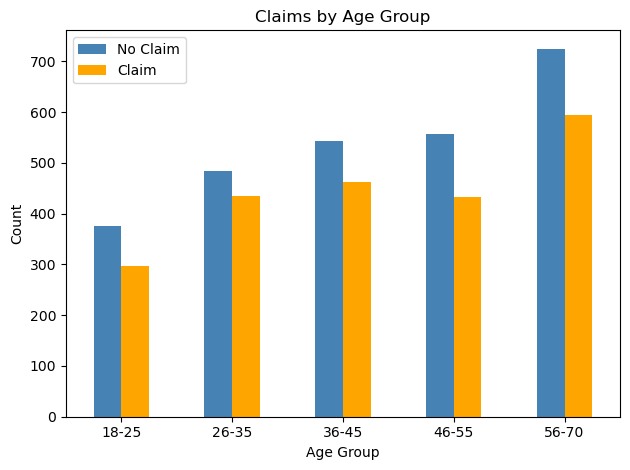

In [7]:
# Group age into bands
data['AGE_GROUP'] = pd.cut(data['AGE'],
                          bins=[18, 25, 35, 45, 55, 70],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-70'])

age_claim = data.groupby(['AGE_GROUP', 'CLAIM']).size().unstack(fill_value=0)
age_claim.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Claims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(['No Claim', 'Claim'])
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

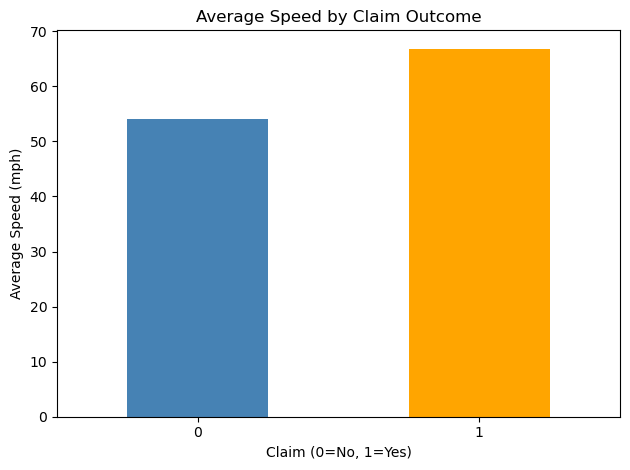

In [8]:
#Average Speed by Risk

speed_claim = data.groupby('CLAIM')['SPEED_AVG'].mean()
speed_claim.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Average Speed by Claim Outcome')
plt.xlabel('Claim (0=No, 1=Yes)')
plt.ylabel('Average Speed (mph)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

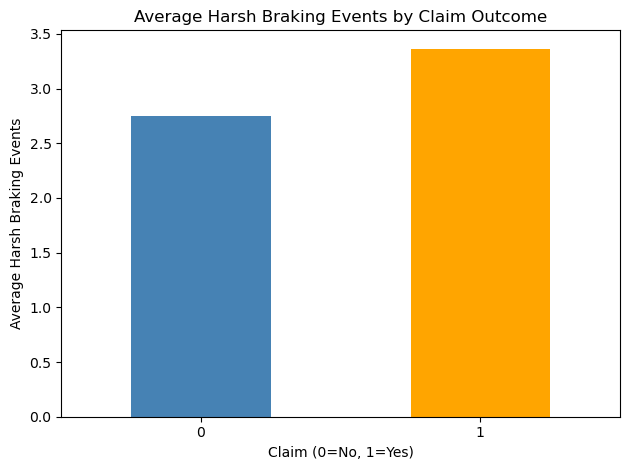

In [18]:
#Harsh Braking vs Claim
braking_claim = data.groupby('CLAIM')['HARSH_BRAKING'].mean()
braking_claim.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Average Harsh Braking Events by Claim Outcome')
plt.xlabel('Claim (0=No, 1=Yes)')
plt.ylabel('Average Harsh Braking Events')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

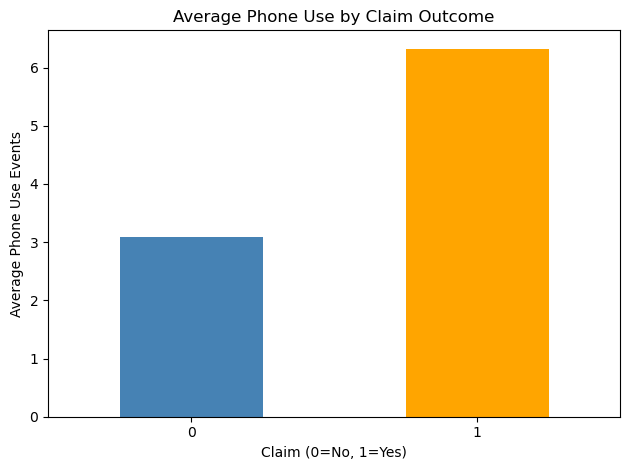

In [17]:
#Phone Use vs Claim
phone_claim = data.groupby('CLAIM')['PHONE_USE'].mean()
phone_claim.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Average Phone Use by Claim Outcome')
plt.xlabel('Claim (0=No, 1=Yes)')
plt.ylabel('Average Phone Use Events')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

My EDA showed four clear risk signals in the data.
Older drivers, higher average speeds, frequent harsh 
braking, and phone use while driving all correlated 
strongly with making a claim. These became the key 
features in my risk scoring model.

In [9]:
X = data.drop(columns=['CLAIM', 'AGE_GROUP', 'RISK_SCORE_RAW'])
y = data['CLAIM']

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['AGE', 'SPEED_AVG', 'SPEED_MAX', 'HARSH_BRAKING', 'HARSH_ACCELERATION', 'NIGHT_DRIVING_PCT', 'MILES_PER_WEEK', 'PHONE_USE', 'GENDER', 'VEHICLE_AGE']
X shape: (5000, 10)
y shape: (5000,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (4000, 10)
Test set: (1000, 10)


In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, rf_predictions,
      target_names=['No Claim', 'Claim']))

Random Forest Accuracy: 83.00%

Detailed Report:
              precision    recall  f1-score   support

    No Claim       0.85      0.84      0.84       548
       Claim       0.81      0.81      0.81       452

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



The model correctly predicted whether a driver 
would make a claim 83 out of every 100 times.
That is a strong result for a telematics model.
When the model said someone would NOT claim 
it was right 85% of the time.
When the model said someone WOULD claim 
it was right 81% of the time.

Top features predicting claims:
              Feature  Importance
7           PHONE_USE    0.381906
1           SPEED_AVG    0.199442
5   NIGHT_DRIVING_PCT    0.108762
3       HARSH_BRAKING    0.059129
2           SPEED_MAX    0.056260
6      MILES_PER_WEEK    0.055621
0                 AGE    0.049073
4  HARSH_ACCELERATION    0.043263
9         VEHICLE_AGE    0.038799
8              GENDER    0.007746


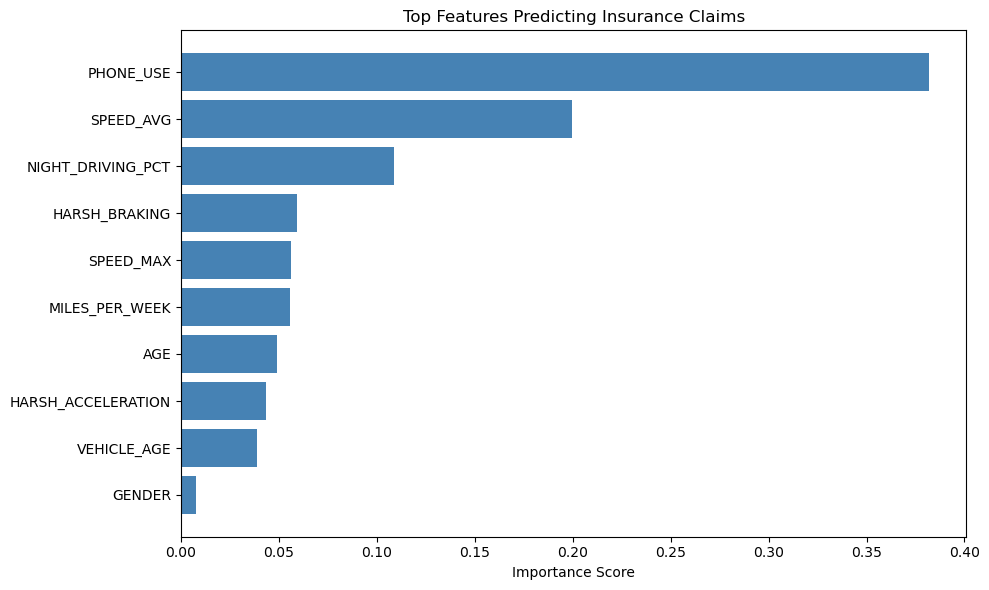

In [15]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top features predicting claims:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top Features Predicting Insurance Claims')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [17]:
import os

# Add risk scores to test data
data_export = X_test.copy()
data_export['CLAIM'] = y_test.values
data_export['RISK_SCORE'] = rf.predict_proba(X_test)[:, 1]
data_export['RISK_CATEGORY'] = pd.cut(
    data_export['RISK_SCORE'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Save to same folder as notebook
data_export.to_csv('telematics_risk_scored.csv', index=False)

print("CSV exported successfully!")
print(f"\nRows: {len(data_export)}")
print("\nRisk breakdown:")
print(data_export['RISK_CATEGORY'].value_counts())
print(f"\nSaved in: {os.getcwd()}")

CSV exported successfully!

Rows: 1000

Risk breakdown:
RISK_CATEGORY
Low Risk       402
High Risk      388
Medium Risk    210
Name: count, dtype: int64

Saved in: C:\Users\dell


In [18]:
import os

# Recreate AGE_GROUP from AGE
data_export['AGE_GROUP'] = pd.cut(data_export['AGE'],
                    bins=[18, 25, 35, 45, 55, 70],
                    labels=['18-25', '26-35', '36-45', '46-55', '56-70'])

# Save again
data_export.to_csv('telematics_risk_scored.csv', index=False)
print("CSV updated!")
print(data_export['AGE_GROUP'].value_counts())

CSV updated!
AGE_GROUP
56-70    262
46-55    207
36-45    197
26-35    187
18-25    135
Name: count, dtype: int64
